# CIFAR-10 Dataset for CNN

In [26]:
import copy
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


#### Loading in the CIFAR-10 training and test data, normalizing, and checking some images to make sure the labels are correct so we know the data loading process worked

In [16]:
# calculate mean and std deviation per channel in the training split so we can properly normalize later
# 1. Load training data WITHOUT normalization
stats_transform = transforms.Compose([
    transforms.ToTensor()
])

full_trainset_for_stats = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=stats_transform
)

train_size = int(0.9 * len(full_trainset_for_stats))
val_size = len(full_trainset_for_stats) - train_size

trainset_for_stats, valset_for_stats = torch.utils.data.random_split(
    full_trainset_for_stats,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

# 2. Stack training-split images
x = torch.stack([img for img, label in trainset_for_stats])
# x shape: (45000, 3, 32, 32)

# 3. Compute mean/std per channel
mean = x.mean(dim=(0, 2, 3))
std = x.std(dim=(0, 2, 3))

print("train size:", len(trainset_for_stats))
print("validation size:", len(valset_for_stats))
print("mean:", mean)
print("std:", std)

train size: 45000
validation size: 5000
mean: tensor([0.4917, 0.4823, 0.4467])
std: tensor([0.2471, 0.2435, 0.2616])


In [17]:
# Now, use the calculated train-split stats to transform the train, validation, and test data
# 4. Use those values in the real transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

# 5. Load train/test datasets using the SAME normalization
full_trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainset = torch.utils.data.Subset(full_trainset, trainset_for_stats.indices)
valset = torch.utils.data.Subset(full_trainset, valset_for_stats.indices)

batch_size = 64

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

valloader = torch.utils.data.DataLoader(
    valset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

In [18]:
# defining the classes
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [19]:
# create function to process and display images
def imshow(img):
    img = img * std.view(3,1,1) + mean.view(3,1,1)

    npimg = img.numpy()

    plt.imshow(np.transpose(npimg, (1, 2, 0)))

  cat  frog   car   dog


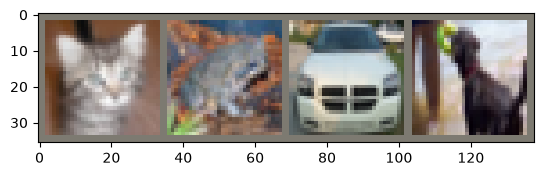

In [20]:
# actually plot the images and labels
dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

#### Defining the model and training

In [21]:
# Defining our model subclass and instantiating
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # input is 3 channels x 32 pixels high x 32 pixels wide
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=(5,5))
        # use (N - F + 2P)/S + 1 to calculate the height x width of each channel
        # N = size of input tensor (per channel), F = kernel (filter) size, P = padding size, S = stride length
        # ex. for N = 32, F = 5, P = 0, S = 1
        # output of conv1 is (32 - 5 + 0)/1 + 1 = 28, so 28 x 28
        self.pool = nn.MaxPool2d(2,2)
        # output of pooling is (28 - 2 + 0)/2 + 1 = 14 x 14. Note: S = 2 for pooling size with 2 x 2 max pooling
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(5,5))
        # output of conv2 is (14 - 5 + 0)/1 + 1 = 10 x 10
        # then, the same pooling as above (2 x 2) will be used:
        # (10 - 2 + 0)/1 + 1 = 5 x 5. This is where the fc1 layer gets its input size: still 16 channels, each 5 x 5
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16*5*5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net().to(device)

#### Shape table for the above CNN
| Layer   | Output Shape |
|----------|--------------|
| Input    | (3, 32, 32) |
| Conv1    | (6, 28, 28) |
| Pool1    | (6, 14, 14) |
| Conv2    | (16, 10, 10) |
| Pool2    | (16, 5, 5) |
| Flatten  | (400,) |
| FC1      | (120,) |
| FC2      | (84,) |
| FC3      | (10,) |

In [22]:
# creating loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [23]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy


history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

max_epochs = 50
patience = 5
min_delta = 0.0

best_val_loss = float('inf')
best_epoch = 0
best_model_state = copy.deepcopy(net.state_dict())
epochs_without_improvement = 0

for epoch in range(max_epochs):
    train_loss, train_accuracy = train_one_epoch(net, trainloader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate(net, valloader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)

    improved = val_loss < best_val_loss - min_delta
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(net.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f'Epoch {epoch+1:02d}: '
        f'train loss {train_loss:.3f}, train acc {train_accuracy:.3f}, '
        f'val loss {val_loss:.3f}, val acc {val_accuracy:.3f}'
    )

    if epochs_without_improvement >= patience:
        print(f'Early stopping at epoch {epoch+1}. Best epoch was {best_epoch}.')
        break

net.load_state_dict(best_model_state)

print('Finished Training')


Epoch 01: train loss 2.191, train acc 0.191, val loss 2.015, val acc 0.285
Epoch 02: train loss 1.868, train acc 0.326, val loss 1.782, val acc 0.342
Epoch 03: train loss 1.663, train acc 0.395, val loss 1.601, val acc 0.422
Epoch 04: train loss 1.524, train acc 0.444, val loss 1.498, val acc 0.453
Epoch 05: train loss 1.442, train acc 0.478, val loss 1.421, val acc 0.489
Epoch 06: train loss 1.383, train acc 0.502, val loss 1.385, val acc 0.494
Epoch 07: train loss 1.334, train acc 0.520, val loss 1.365, val acc 0.511
Epoch 08: train loss 1.292, train acc 0.538, val loss 1.323, val acc 0.532
Epoch 09: train loss 1.257, train acc 0.550, val loss 1.299, val acc 0.540
Epoch 10: train loss 1.223, train acc 0.564, val loss 1.253, val acc 0.559
Epoch 11: train loss 1.186, train acc 0.581, val loss 1.242, val acc 0.558
Epoch 12: train loss 1.156, train acc 0.588, val loss 1.189, val acc 0.581
Epoch 13: train loss 1.126, train acc 0.601, val loss 1.176, val acc 0.585
Epoch 14: train loss 1.09

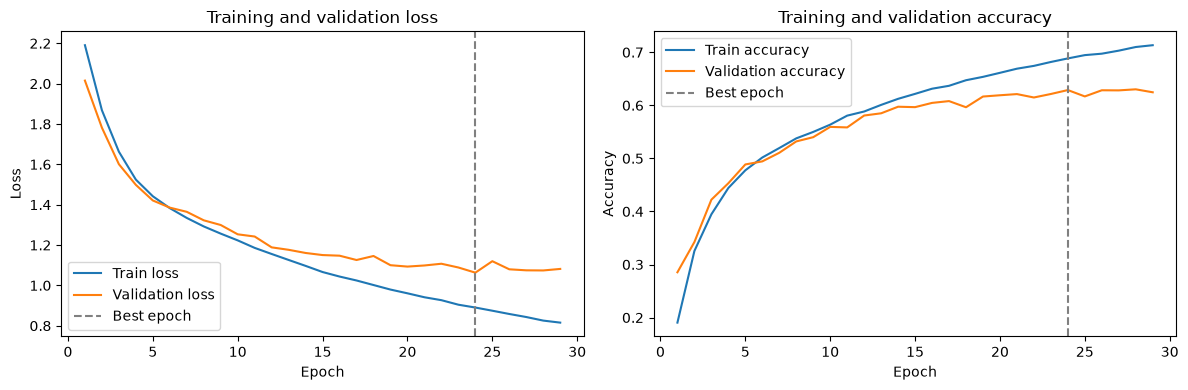

In [27]:
figures_dir = Path('../figures')
figures_dir.mkdir(exist_ok=True)

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], label='Train loss')
axes[0].plot(epochs, history['val_loss'], label='Validation loss')
axes[0].axvline(best_epoch, color='gray', linestyle='--', label='Best epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and validation loss')
axes[0].legend()

axes[1].plot(epochs, history['train_accuracy'], label='Train accuracy')
axes[1].plot(epochs, history['val_accuracy'], label='Validation accuracy')
axes[1].axvline(best_epoch, color='gray', linestyle='--', label='Best epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and validation accuracy')
axes[1].legend()

fig.tight_layout()
fig.savefig(figures_dir / 'training_validation_curves.png', dpi=150)
plt.show()

In [24]:
# checking accuracy
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10,000 test images: {correct * 100 / total :2f} %')

Accuracy of the network on the 10,000 test images: 64.130000 %
